<div class="alert alert-info"> <b> 👋 Привет Станислав! Рада познакомиться, конечно, проще на "ты" </b>

🤓Спасибо за комментарии и замечания, надеюсь, они помогли мне сделать проект лучше)
    

    Я вернула все города, изменила параметр выбора количества Топ-N, также обозначила их на карте.
    Добавила параметр времени использования, как-то забыла о нём в первый раз. На лист с NPS тоже 🙃
</div>
Дублирую ссылку и с нетерпением жду обратной связи:

https://public.tableau.com/app/profile/rozaliya.suleymanova/viz/_17161564349270/NPS_5?publish=yes
</div>

<div class="alert alert-info">
Лёгкой проверки и хорошего дня!
</div>

<div class="alert alert-success">
✔️ <b>Комментарий с комплиментом ревьюера по Дашборду в2:</b>

    
Здорово, что ты доработала фильтры и проанализировала пользователей по lifetime.

<div class="alert alert-danger">
❌ <b>Комментарий с замечанием ревьюера по Дашборду в2:</b> 


Ниже прикладываю скрин 3-его дашборда, обрати внимание, что на нем нет фильтра по городам и на карте таким образом отображаются не все городм и соответсвенно мы не можем сделать полный анализ и определить город с наибольшим или наименьшим nps.    

</div>

<div class="alert alert-info"> <b> 🤓 Да, спасибо, исправила </b>
    
И карту распределения по лояльности исправила ещё с разбивкой по категориям 🙃

https://public.tableau.com/app/profile/rozaliya.suleymanova/viz/_17161564349270/NPS_5?publish=yes

<div class="alert alert-success">
✔️ <b>Комментарий с комплиментом ревьюера по Дашборду в3:</b>

Отлично, спасибо за проработку дашборда, молодец, получилась качественная работа!

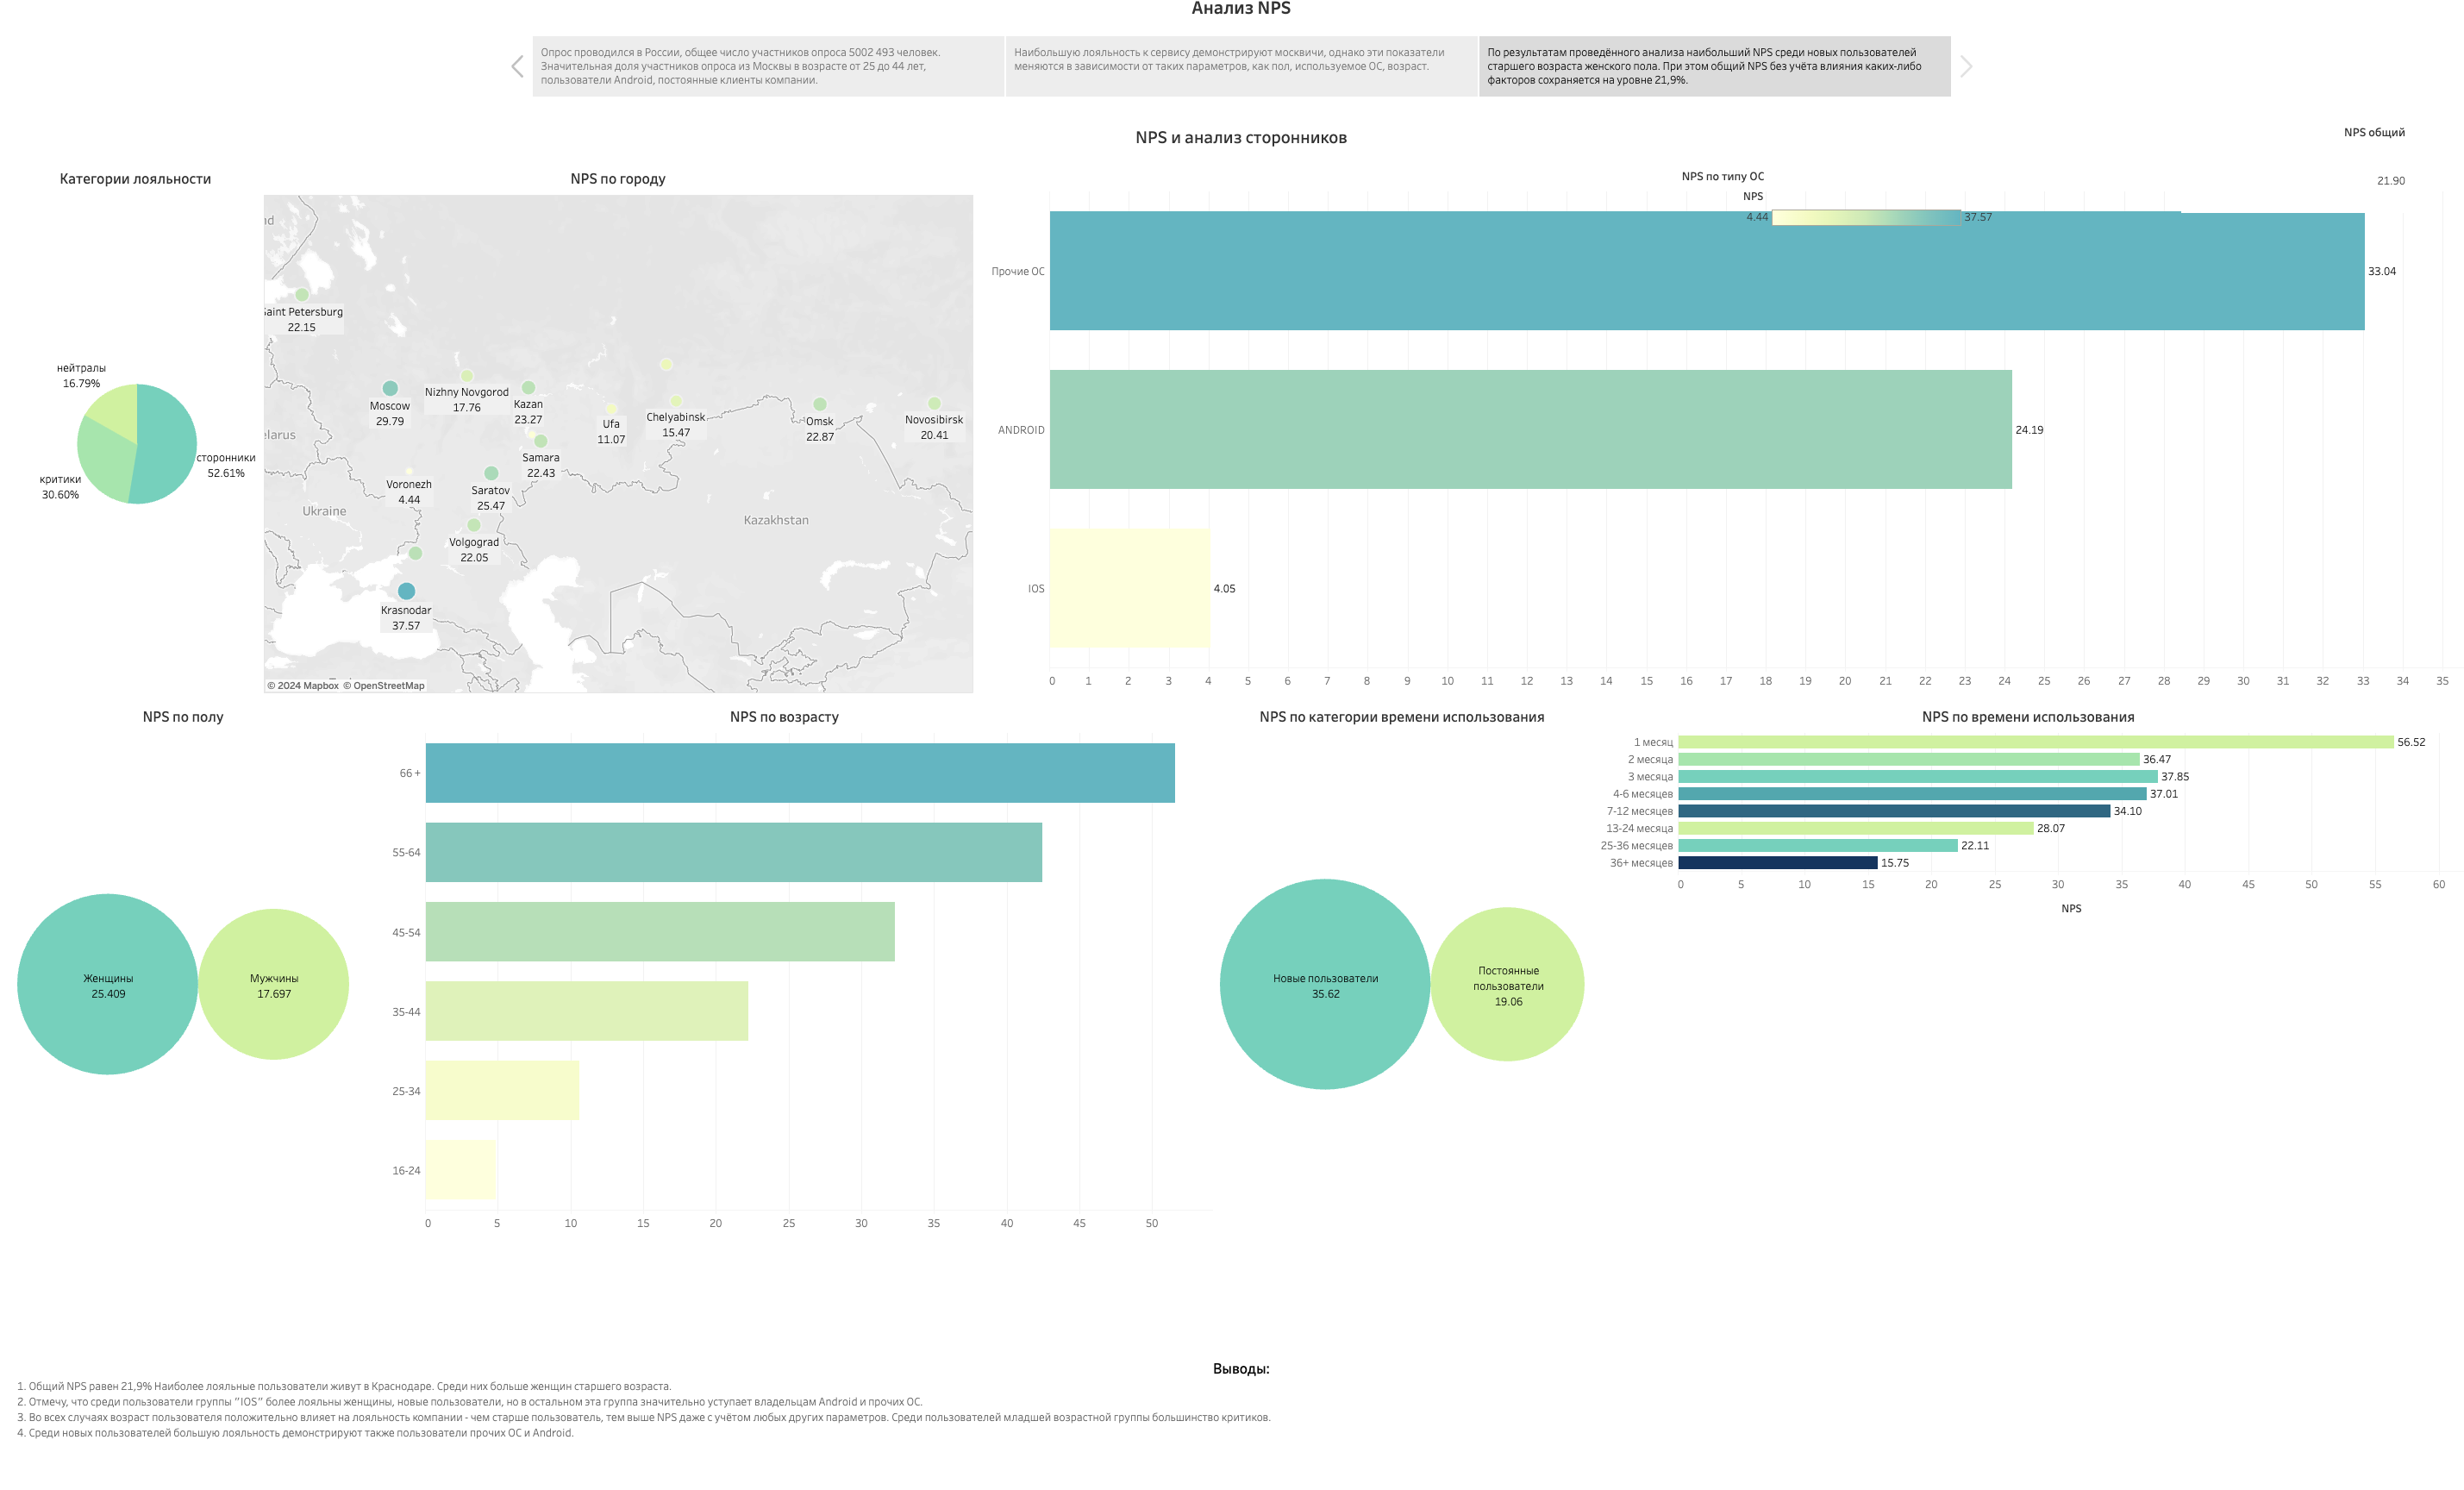

<div style="border:solid Chocolate 2px; padding: 40px">

Розалия привет, меня зовут Станислав, и я буду проверять твой проект. Предлагаю общаться на «ты», но если это неудобно - дай знать, и мы перейдем на «вы».
Это учебный проект и здесь не стоит бояться делать ошибки, я хочу поделиться своим опытом и помочь тебе стать аналитиком данных.
Уже выполнена большая работа над проектом, давай сделаем его еще лучше. Ниже ты найдешь мои комментарии - пожалуйста, не перемещай, не изменяй и не удаляй их. Я буду использовать цветовую разметку:

<div class="alert alert-danger">
❌ <b>Комментарий с замечанием ревьюера:</b> Так выделены самые важные замечания. Как только ты их исправишь проект будет принят. </div>

<div class="alert alert-warning">
⚠️  <b>Комментарий с небольшим замечанием или советом ревьюера:</b> Так выделены небольшие замечания или советы. 
</div>

<div class="alert alert-success">
✔️ <b>Комментарий с комплиментом ревьюера:</b> Так я выделяю все остальные комментарии.</div>

Давай работать над проектом в диалоге: если ты что-то меняешь в проекте или отвечаешь на мои комментарии — пиши об этом.
Мне будет легче отследить изменения, если ты выделишь свои комментарии:
<div class="alert alert-info"> <b>🎓 Комментарий студента:</b> Например, вот так.</div>
Всё это поможет выполнить повторную проверку твоего проекта оперативнее.
</div>


# Исследование по определению потребительской лояльности (NPS)

## Описание проекта.

Заказчик этого исследования — большая телекоммуникационная компания, которая оказывает услуги на территории всего СНГ. Перед компанией стоит задача определить текущий уровень потребительской лояльности, или NPS (от англ. Net Promoter Score), среди клиентов из России.   

Чтобы определить уровень лояльности, клиентам задавали классический вопрос: «Оцените по шкале от 1 до 10 вероятность того, что вы порекомендуете компанию друзьям и знакомым».  

Чтобы оценить результаты опроса, оценки обычно делят на три группы:
9-10 баллов — «cторонники» (англ. promoters);
7-8 баллов — «нейтралы» (англ. passives);
0-6 баллов — «критики» (англ. detractors).  

Значение NPS варьируется от -100% (когда все клиенты «критики») до 100% (когда все клиенты лояльны к сервису). Но это крайние случаи, которые редко встретишь на практике.  

Интерпретируя результаты NPS-опросов, следует также помнить, что само значение мало о чём говорит. Однако исследования показывают, что клиенты-сторонники полезны любому бизнесу. Они чаще других повторно совершают покупки, активнее тестируют обновления и приводят в сервис своих друзей и знакомых. Поэтому NPS остаётся одной из важнейших метрик бизнеса.  

## Настройка параметров анализа (#settings)
<a id="settings"></a>

In [1]:
import os
import pandas as pd
import numpy as np

from sqlalchemy import create_engine

## Выгрузка данных (#data)
<a id="start"></a>

In [2]:
path_to_db_local = 'telecomm_csi.db'
path_to_db_platform = '/datasets/telecomm_csi.db'
path_to_db = None

if os.path.exists(path_to_db_local):
    path_to_db = path_to_db_local
elif os.path.exists(path_to_db_platform):
    path_to_db = path_to_db_platform
else:
    raise Exception('Файл с базой данных SQLite не найден!')

if path_to_db:
    engine = create_engine(f'sqlite:///{path_to_db}', echo=False)

In [3]:
query = """
    SELECT u.user_id,
           u.lt_day,
           (u.lt_day<=365) AS is_new,
           u.age,
           (CASE 
                WHEN u.gender_segment = 0 THEN 'man'
                ELSE 'woman'
            END) AS gender_segment,
           u.os_name,
           u.cpe_type_name,
           l.country,
           l.city,
           ages.title AS age_segment,
           ts.title AS traffic_segment,
           ls.title AS lifetime_segment,
           u.nps_score,
           (CASE 
                WHEN u.nps_score > 8 THEN 'cторонники'
                WHEN u.nps_score < 7 THEN 'критики'
                ELSE 'нейтралы'
            END) AS nps_group
    FROM user AS u
    JOIN location AS l ON u.location_id=l.location_id
    JOIN age_segment AS ages ON u.age_gr_id=ages.age_gr_id
    JOIN traffic_segment AS ts ON u.tr_gr_id=ts.tr_gr_id
    JOIN lifetime_segment AS ls ON u.lt_gr_id=ls.lt_gr_id
"""

In [4]:
df = pd.read_sql(query, engine)
df.head(20)

,user_id,lt_day,is_new,age,gender_segment,os_name,cpe_type_name,country,city,age_segment,traffic_segment,lifetime_segment,nps_score,nps_group
0,A001A2,2320,0,45.0,woman,ANDROID,SMARTPHONE,Россия,Уфа,05 45-54,04 1-5,08 36+,10,cторонники
1,A001WF,2344,0,53.0,man,ANDROID,SMARTPHONE,Россия,Киров,05 45-54,04 1-5,08 36+,10,cторонники
2,A003Q7,467,0,57.0,man,ANDROID,SMARTPHONE,Россия,Москва,06 55-64,08 20-25,06 13-24,10,cторонники
3,A004TB,4190,0,44.0,woman,IOS,SMARTPHONE,Россия,РостовнаДону,04 35-44,03 0.1-1,08 36+,10,cторонники
4,A004XT,1163,0,24.0,man,ANDROID,SMARTPHONE,Россия,Рязань,02 16-24,05 5-10,08 36+,10,cторонники
5,A005O0,5501,0,42.0,woman,ANDROID,SMARTPHONE,Россия,Омск,04 35-44,05 5-10,08 36+,6,критики
6,A0061R,1236,0,45.0,man,ANDROID,SMARTPHONE,Россия,Уфа,05 45-54,06 10-15,08 36+,10,cторонники
7,A009KS,313,1,35.0,man,ANDROID,SMARTPHONE,Россия,Москва,04 35-44,13 45-50,05 7-12,10,cторонники
8,A00AES,3238,0,36.0,woman,ANDROID,SMARTPHONE,Россия,СанктПетербург,04 35-44,04 1-5,08 36+,10,cторонники
9,A00F70,4479,0,54.0,woman,ANDROID,SMARTPHONE,Россия,Волгоград,05 45-54,07 15-20,08 36+,9,cторонники


In [5]:
df.to_csv('telecomm_csi_tableau.csv', index=False)

Ссылка на презентацию с анализом: https://public.tableau.com/app/profile/rozaliya.suleymanova/viz/_17161564349270/NPS_5?publish=yes

<div class="alert alert-success">
✔️ <b>Комментарий с комплиментом ревьюера по Дашборду:</b>

    
Отличный анализ групп по пользователям, добавлены графики по основным категориям: полу, возрасту, городам, выведено соотношение новых и старых пользователей.
    
Здорово, что сделан анализ по группам.
    
Добавлен подробный анализ NPS по нескольким разрезам.
</div>


<div class="alert alert-danger">
❌ <b>Комментарий с замечанием ревьюера по Дашборду:</b> 

Есть несколько замечаний, которые необходимо скорректировать:    

    
- доработай, пожалуйста, анализ участников по городам, у нас много городов в базе и важно проанализировать их всех
    
- добавь, пожалуйста, анализ уровня лояльности по времени пользования сервисом (lifetime)
    

</div>



In [ ]:
# IF [city] = 'Москва' THEN 'Moscow'
# ELSEIF [city] = 'СанктПетербург' THEN 'Saint Petersburg'
# ELSEIF [city] = 'Новосибирск' THEN 'Novosibirsk'
# ELSEIF [city] = 'Екатеринбург' THEN 'Yekaterinburg'
# ELSEIF [city] = 'Казань' THEN 'Kazan'
# ELSEIF [city] = 'НижнийНовгород' THEN 'Nizhny Novgorod'
# ELSEIF [city] = 'Челябинск' THEN 'Chelyabinsk'
# ELSEIF [city] = 'Самара' THEN 'Samara'
# ELSEIF [city] = 'Омск' THEN 'Omsk'
# ELSEIF [city] = 'РостовнаДону' THEN 'Rostov-on-Don'
# END